In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')

1 - One-hot encoding 3 categorical columns.

In [7]:
df = pd.get_dummies(df, columns=["Neighborhood", "Bldg Type", "House Style"], drop_first=True)
# This transformation converts categorical values into numerical format.

2 -  Ordinal encode 1 ordered column.

In [8]:
qual_map = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
df["Exter Qual"] = df["Exter Qual"].map(qual_map)
# Ordinal encoding was applied to the feature Exter Qual, as it represents an ordered category from poor to excellent.

3 -  Scaling 2 numerical columns.

In [9]:
from sklearn.preprocessing import StandardScaler # I used AI to determine the appropriate library for scale.

scaler = StandardScaler()
df[["Gr Liv Area", "Total Bsmt SF"]] = scaler.fit_transform(df[["Gr Liv Area", "Total Bsmt SF"]])
# This ensures that all features have a mean of 0 and a standard deviation of 1, improving model performance.

4 -  Create 2 domain features.

In [10]:
# I created the 'price_per_sqft' feature by dividing 'SalePrice' by 'Gr Liv Area'. this helps to see the actual value of each square foot, so the house size doesn't distract the model from the real price efficiency.
df["price_per_squarefoot"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, np.nan)
df["price_per_squarefoot"] = df["price_per_squarefoot"].fillna(0)

df["house_age"] = df["Yr Sold"] - df["Year Built"] # This provides more meaningful information than using the raw year values.

5 -  Create 1 interaction feature.

In [11]:
df["QualityArea"] = df["Overall Qual"] * df["Gr Liv Area"]
# This is  interaction shows that a big house with high quality should be much more expensive than a big house with low quality.

6 -  Log-transform 1 skewed column.

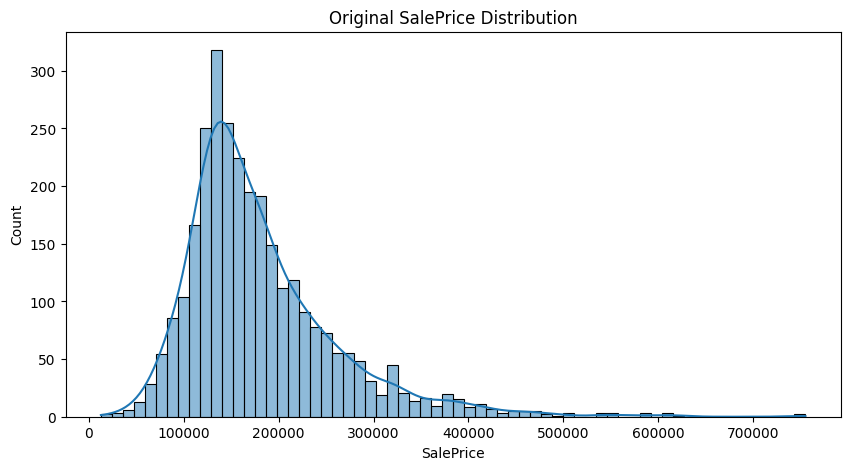

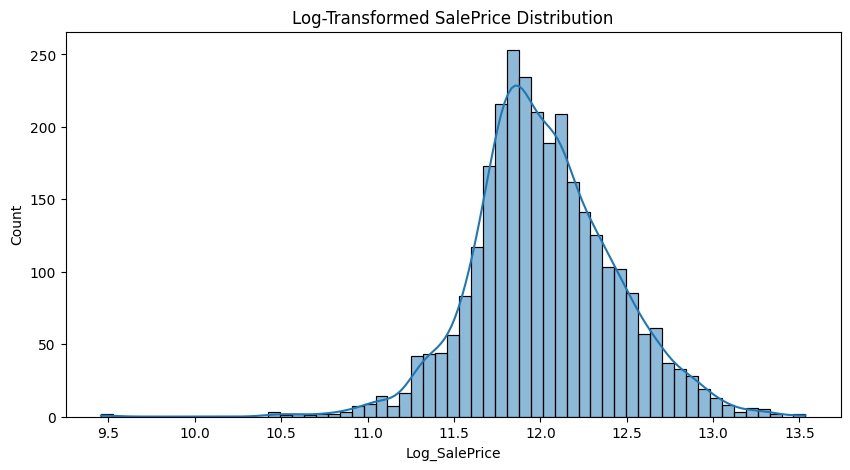

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'], kde=True) # The KDE is a smooth line that shows the data's shape, helping me see if the prices follow a normal bell curve or are skewed.
plt.title('Original SalePrice Distribution')
plt.show()

df['Log_SalePrice'] = np.log1p(df['SalePrice'])
# I used Log-transform on 'SalePrice' because the original data was skewed with some very expensive houses. after the transformation the distribution looks more like a normal bell curve(that we had learned previously), which helps the model make better predictions.

plt.figure(figsize=(10,5))
sns.histplot(df['Log_SalePrice'], kde=True)
plt.title('Log-Transformed SalePrice Distribution')
plt.show()

7 -  Bin 1 column into meaningful groups.

In [13]:
bins = [0, 10, 30, 150]

# Set the names for categories.
group_names = ['New', 'Recent', 'Old']

df['age_group'] = pd.cut(df['house_age'], bins=bins, labels=group_names)
# This simplifies the data for the model because a house's general age group is often more important than the exact number of years.

8 - Removing redundant features.

In [14]:
threshold = 0.95

corr_matrix = df.corr(numeric_only=True).abs() # I encountered a ValueError when calculating the correlation matrix because the dataset contains non numeric columns. I resolved this by setting numeric_only=True.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
df = df.drop(columns=to_drop)
# Dropping these redundant columns helps the model run faster and prevents it from getting confused by repeated data.

print(f"Features dropped because correlation > {threshold}: {to_drop}")
# I didn't understand this step, so I returned in the course slides and find the right formula. (page:172,day:24)

Features dropped because correlation > 0.95: ['Yr Sold', 'house_age', 'QualityArea']
